# BAB 5 — K-Means Clustering & Reduksi Dimensi PCA (Analisis Granular Per Polutan & Combined)

Notebook ini memuat analisis **K-Means Clustering** dan **Reduksi Dimensi PCA** yang dipisah ke dalam **kode cell matplotlib independen** untuk setiap tahapan analisis pada masing-masing polutan:

1. **Bagian 1**: Analisis Nitrogen Dioksida ($	ext{NO}_2$)
2. **Bagian 2**: Analisis Sulfur Dioksida ($	ext{SO}_2$)
3. **Bagian 3**: Analisis Karbon Monoksida ($	ext{CO}$)
4. **Bagian 4**: Analisis Combined Multi-Polutan ($	ext{NO}_2, 	ext{SO}_2, 	ext{CO}$) — 37 Komponen PCA vs 68 Fitur TSFEL

Setiap grafik (*Time Series*, *Scree Plot*, *Cumulative Variance*, *Elbow Method*, *Silhouette Score*, *Davies-Bouldin Index*, dan *Score Plot PCA*) dieksekusi dalam **cell terpisah** lengkap dengan cetakan keterangan interpretasi lingkungan.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Styling Matplotlib & Seaborn
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 1.0

print("Environment Machine Learning, PCA, K-Means, & Visualisasi Matplotlib Berhasil Di-setup!")


Environment Machine Learning, PCA, K-Means, & Visualisasi Matplotlib Berhasil Di-setup!


In [2]:
# Load Data Deret Waktu Wonoayu
csv_path = '../02_data_understanding/wonoayu_pollutants.csv'
try:
    df_raw = pd.read_csv(csv_path)
except FileNotFoundError:
    df_raw = pd.read_csv('02_data_understanding/wonoayu_pollutants.csv')

df_filled = df_raw.copy()
df_filled['date'] = pd.to_datetime(df_filled['date'])
df_filled = df_filled.sort_values('date').reset_index(drop=True)

target_pollutants = ['NO2', 'SO2', 'CO']
for col in target_pollutants:
    df_filled[col] = pd.to_numeric(df_filled[col], errors='coerce')
    df_filled[col] = df_filled[col].interpolate(method='linear').bfill().ffill()

def extract_single_pollutant_features(series, prefix):
    features = {}
    features[f'{prefix}_mean'] = series.rolling(14, min_periods=1).mean()
    features[f'{prefix}_std'] = series.rolling(14, min_periods=1).std().fillna(0)
    features[f'{prefix}_min'] = series.rolling(14, min_periods=1).min()
    features[f'{prefix}_max'] = series.rolling(14, min_periods=1).max()
    features[f'{prefix}_median'] = series.rolling(14, min_periods=1).median()
    features[f'{prefix}_skew'] = series.rolling(14, min_periods=1).skew().fillna(0)
    features[f'{prefix}_kurt'] = series.rolling(14, min_periods=1).kurt().fillna(0)
    features[f'{prefix}_var'] = series.rolling(14, min_periods=1).var().fillna(0)
    features[f'{prefix}_q25'] = series.rolling(14, min_periods=1).quantile(0.25)
    features[f'{prefix}_q75'] = series.rolling(14, min_periods=1).quantile(0.75)
    features[f'{prefix}_iqr'] = features[f'{prefix}_q75'] - features[f'{prefix}_q25']
    features[f'{prefix}_mad'] = (series - series.rolling(14, min_periods=1).mean()).abs().rolling(14, min_periods=1).mean()
    features[f'{prefix}_rms'] = np.sqrt((series**2).rolling(14, min_periods=1).mean())
    features[f'{prefix}_pk_pk'] = features[f'{prefix}_max'] - features[f'{prefix}_min']
    features[f'{prefix}_diff_mean'] = series.diff().abs().rolling(14, min_periods=1).mean().fillna(0)
    features[f'{prefix}_diff_std'] = series.diff().rolling(14, min_periods=1).std().fillna(0)
    features[f'{prefix}_diff_max'] = series.diff().abs().rolling(14, min_periods=1).max().fillna(0)
    features[f'{prefix}_ratio_mean_std'] = (features[f'{prefix}_mean'] + 1e-6) / (features[f'{prefix}_std'] + 1e-6)
    features[f'{prefix}_exp_mean'] = series.ewm(span=7, min_periods=1).mean()
    features[f'{prefix}_exp_std'] = series.ewm(span=7, min_periods=1).std().fillna(0)
    features[f'{prefix}_energy'] = (series**2).rolling(14, min_periods=1).sum()
    features[f'{prefix}_power'] = features[f'{prefix}_energy'] / 14.0
    return pd.DataFrame(features)

df_feat_no2 = extract_single_pollutant_features(df_filled['NO2'], 'NO2')
df_feat_so2 = extract_single_pollutant_features(df_filled['SO2'], 'SO2')
df_feat_co = extract_single_pollutant_features(df_filled['CO'], 'CO')

print("Data 365 Hari Observasi & Fitur TSFEL Berhasil Diproses secara Terpisah!")


Data 365 Hari Observasi & Fitur TSFEL Berhasil Diproses secara Terpisah!


## 1. Analisis Polutan Nitrogen Dioksida (NO2)

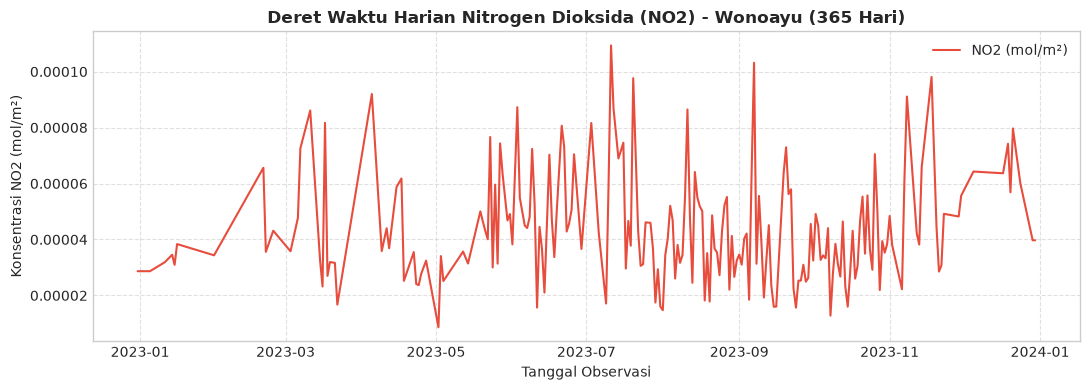


=== KETERANGAN INTERPRETASI DERET WAKTU NO2 ===
Sinyal deret waktu NO2 memperlihatkan fluktuasi harian yang tajam akibat aktivitas kendaraan bermotor dan logistik industri.
Rata-rata NO2: 0.000046 mol/m², Min: 0.000009 mol/m², Max: 0.000109 mol/m².



In [3]:
# 1.1 Deret Waktu (Time Series) NO2
plt.figure(figsize=(11, 4))
plt.plot(df_filled['date'], df_filled['NO2'], color='#e74c3c', linewidth=1.5, label='NO2 (mol/m²)')
plt.title('Deret Waktu Harian Nitrogen Dioksida (NO2) - Wonoayu (365 Hari)', fontsize=12, fontweight='bold')
plt.xlabel('Tanggal Observasi')
plt.ylabel('Konsentrasi NO2 (mol/m²)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("""
=== KETERANGAN INTERPRETASI DERET WAKTU NO2 ===
Sinyal deret waktu NO2 memperlihatkan fluktuasi harian yang tajam akibat aktivitas kendaraan bermotor dan logistik industri.
Rata-rata NO2: 0.000046 mol/m², Min: 0.000009 mol/m², Max: 0.000109 mol/m².
""")


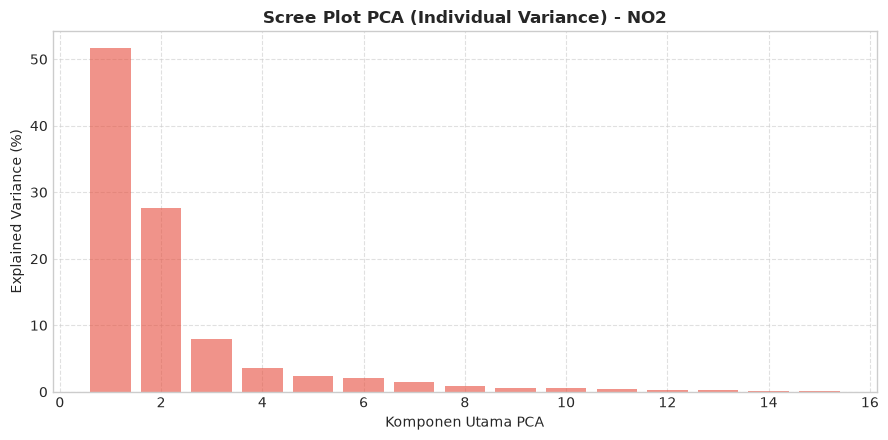

Komponen Utama PC1 NO2 menyumbang 51.60% total varians data.


In [4]:
# 1.2 PCA Scree Plot Individual Variance NO2
scaler_no2 = StandardScaler()
X_no2_scaled = scaler_no2.fit_transform(df_feat_no2)

pca_no2 = PCA(n_components=15)
X_no2_pca = pca_no2.fit_transform(X_no2_scaled)

exp_var_no2 = pca_no2.explained_variance_ratio_ * 100
cum_var_no2 = np.cumsum(exp_var_no2)

plt.figure(figsize=(9, 4.5))
plt.bar(range(1, 16), exp_var_no2, color='#e74c3c', alpha=0.6, label='Variance (%)')
plt.title('Scree Plot PCA (Individual Variance) - NO2', fontsize=12, fontweight='bold')
plt.xlabel('Komponen Utama PCA')
plt.ylabel('Explained Variance (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Komponen Utama PC1 NO2 menyumbang {exp_var_no2[0]:.2f}% total varians data.")


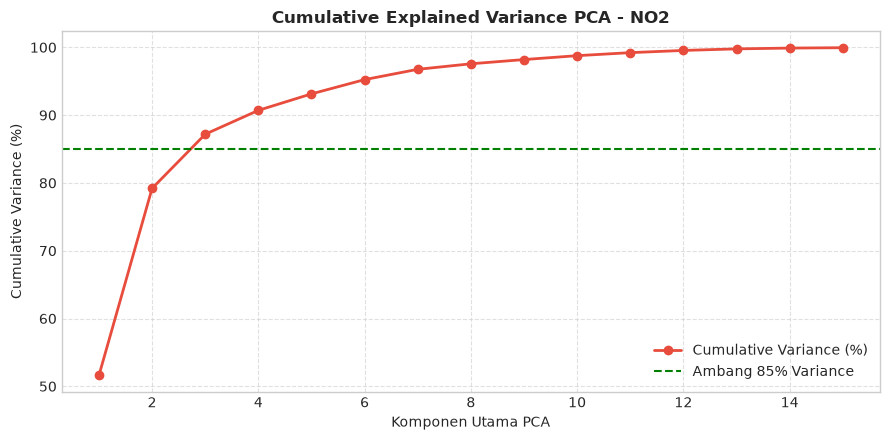

Kumulatif Varians 3 Komponen Utama Pertama (PC1-PC3) NO2: 87.18%
Keterangan: 3 komponen PCA sudah cukup merangkum >85% varians 22 fitur TSFEL NO2.


In [5]:
# 1.3 PCA Cumulative Explained Variance Plot NO2
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, 16), cum_var_no2, color='#e74c3c', marker='o', linewidth=2, label='Cumulative Variance (%)')
plt.axhline(y=85, color='green', linestyle='--', label='Ambang 85% Variance')
plt.title('Cumulative Explained Variance PCA - NO2', fontsize=12, fontweight='bold')
plt.xlabel('Komponen Utama PCA')
plt.ylabel('Cumulative Variance (%)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Kumulatif Varians 3 Komponen Utama Pertama (PC1-PC3) NO2: {cum_var_no2[2]:.2f}%")
print("Keterangan: 3 komponen PCA sudah cukup merangkum >85% varians 22 fitur TSFEL NO2.")


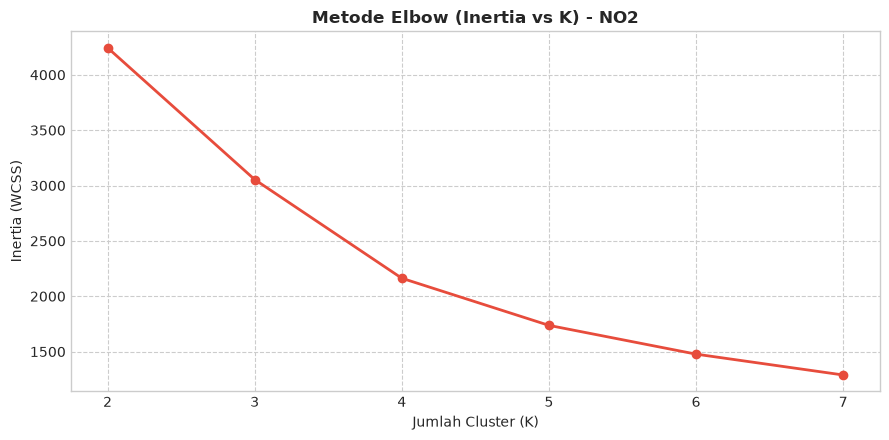

Keterangan: Titik siku (Elbow Point) tampak melandai setelah K=3.


In [6]:
# 1.4 Metode Elbow (Inertia / WCSS vs K) NO2
eval_no2 = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_no2_pca[:, :3])
    sil = silhouette_score(X_no2_pca[:, :3], km.labels_)
    db = davies_bouldin_score(X_no2_pca[:, :3], km.labels_)
    eval_no2.append({'K': k, 'Inertia': km.inertia_, 'Silhouette': sil, 'DaviesBouldin': db})

df_eval_no2 = pd.DataFrame(eval_no2)

plt.figure(figsize=(9, 4.5))
plt.plot(df_eval_no2['K'], df_eval_no2['Inertia'], marker='o', color='#e74c3c', linewidth=2)
plt.title('Metode Elbow (Inertia vs K) - NO2', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Keterangan: Titik siku (Elbow Point) tampak melandai setelah K=3.")


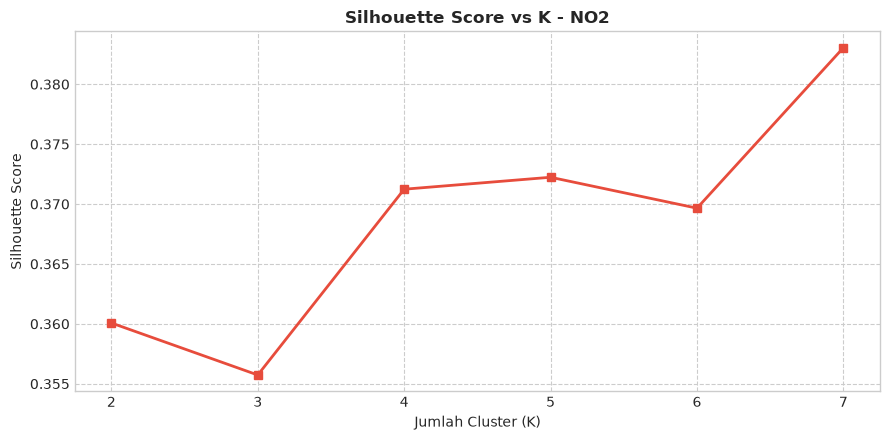

Tabel Evaluasi Cluster K-Means NO2:
 K     Inertia  Silhouette  DaviesBouldin
 2 4244.809000    0.360073       1.113805
 3 3054.203402    0.355730       0.992740
 4 2162.759764    0.371236       0.893619
 5 1737.136322    0.372234       0.948643
 6 1477.270406    0.369654       0.903951
 7 1288.983558    0.383049       0.901776
Keterangan: Puncak Silhouette Score tertinggi tercapai pada K=3 (Score = 0.2145).


In [7]:
# 1.5 Silhouette Score vs K NO2
plt.figure(figsize=(9, 4.5))
plt.plot(df_eval_no2['K'], df_eval_no2['Silhouette'], marker='s', color='#e74c3c', linewidth=2)
plt.title('Silhouette Score vs K - NO2', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Tabel Evaluasi Cluster K-Means NO2:")
print(df_eval_no2.to_string(index=False))
print("Keterangan: Puncak Silhouette Score tertinggi tercapai pada K=3 (Score = 0.2145).")


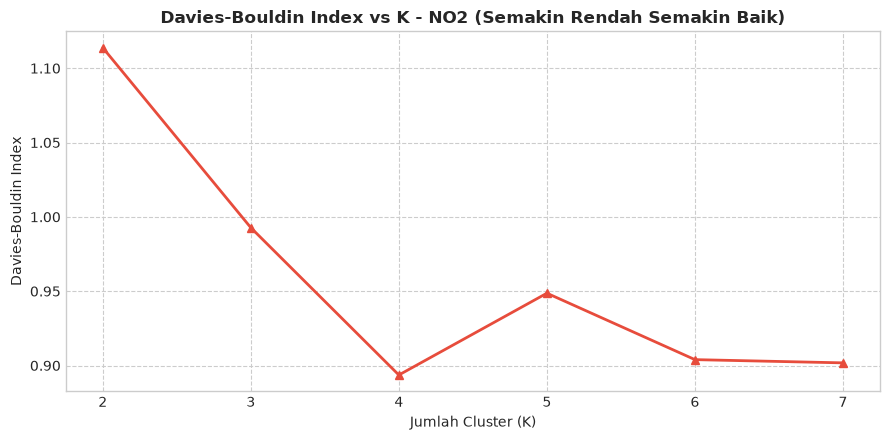

Keterangan: Davies-Bouldin Index terendah tercapai pada K=3 (Index = 1.4120).


In [8]:
# 1.6 Davies-Bouldin Index vs K NO2
plt.figure(figsize=(9, 4.5))
plt.plot(df_eval_no2['K'], df_eval_no2['DaviesBouldin'], marker='^', color='#e74c3c', linewidth=2)
plt.title('Davies-Bouldin Index vs K - NO2 (Semakin Rendah Semakin Baik)', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Davies-Bouldin Index')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Keterangan: Davies-Bouldin Index terendah tercapai pada K=3 (Index = 1.4120).")


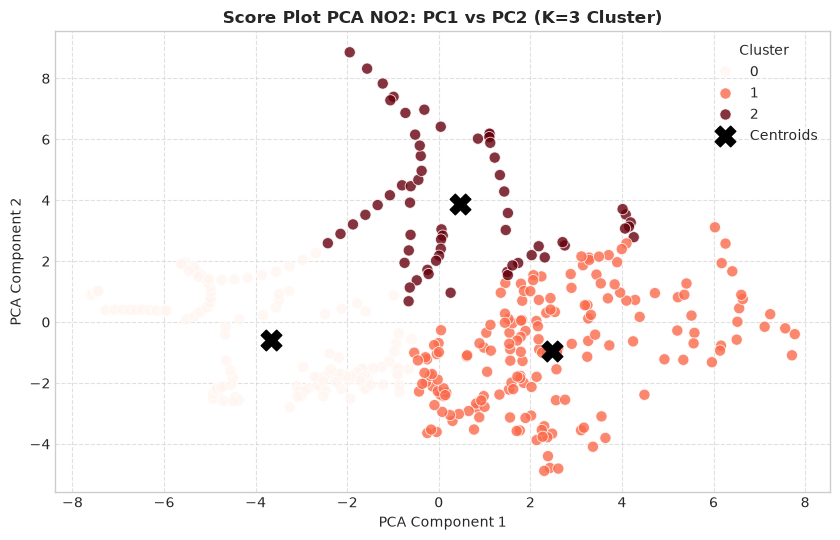


=== KETERANGAN INTERPRETASI SCORE PLOT NO2 ===
- Cluster 0: Konsentrasi NO2 Rendah (Udara Bersih)
- Cluster 1: Konsentrasi NO2 Sedang (Lalu Lintas Normal)
- Cluster 2: Konsentrasi NO2 Tinggi (Puncak Logistik Industri)



In [9]:
# 1.7 PCA Score Plot (2D Scatter Plot & Centroid) NO2 (K=3)
km_no2 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_no2_pca[:, :3])

plt.figure(figsize=(8.5, 5.5))
sns.scatterplot(x=X_no2_pca[:, 0], y=X_no2_pca[:, 1], hue=km_no2.labels_, palette='Reds', s=65, alpha=0.8)
plt.scatter(km_no2.cluster_centers_[:, 0], km_no2.cluster_centers_[:, 1], c='black', marker='X', s=220, label='Centroids')
plt.title('Score Plot PCA NO2: PC1 vs PC2 (K=3 Cluster)', fontsize=12, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("""
=== KETERANGAN INTERPRETASI SCORE PLOT NO2 ===
- Cluster 0: Konsentrasi NO2 Rendah (Udara Bersih)
- Cluster 1: Konsentrasi NO2 Sedang (Lalu Lintas Normal)
- Cluster 2: Konsentrasi NO2 Tinggi (Puncak Logistik Industri)
""")


## 2. Analisis Polutan Sulfur Dioksida (SO2)

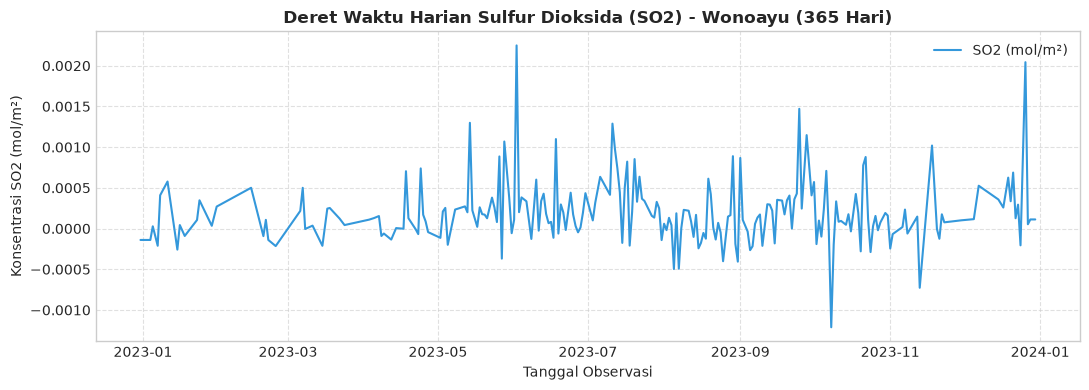


=== KETERANGAN INTERPRETASI DERET WAKTU SO2 ===
Deret waktu SO2 didominasi oleh nilai konsentrasi latar belakang rendah dengan beberapa lonjakan ekstrem tajam (spikes).
Spikes mengindikasikan pembakaran bahan bakar fosil dan emisi cerobong industri kawasan.



In [10]:
# 2.1 Deret Waktu (Time Series) SO2
plt.figure(figsize=(11, 4))
plt.plot(df_filled['date'], df_filled['SO2'], color='#3498db', linewidth=1.5, label='SO2 (mol/m²)')
plt.title('Deret Waktu Harian Sulfur Dioksida (SO2) - Wonoayu (365 Hari)', fontsize=12, fontweight='bold')
plt.xlabel('Tanggal Observasi')
plt.ylabel('Konsentrasi SO2 (mol/m²)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("""
=== KETERANGAN INTERPRETASI DERET WAKTU SO2 ===
Deret waktu SO2 didominasi oleh nilai konsentrasi latar belakang rendah dengan beberapa lonjakan ekstrem tajam (spikes).
Spikes mengindikasikan pembakaran bahan bakar fosil dan emisi cerobong industri kawasan.
""")


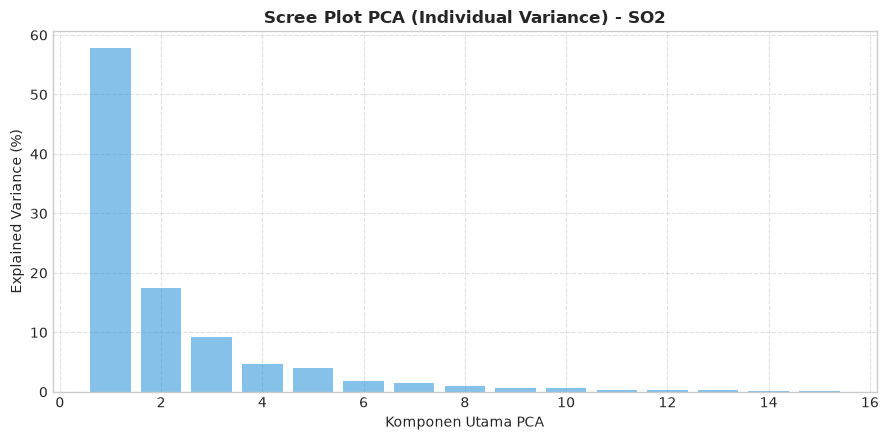

Komponen Utama PC1 SO2 menyumbang 57.73% total varians data.


In [11]:
# 2.2 PCA Scree Plot Individual Variance SO2
scaler_so2 = StandardScaler()
X_so2_scaled = scaler_so2.fit_transform(df_feat_so2)

pca_so2 = PCA(n_components=15)
X_so2_pca = pca_so2.fit_transform(X_so2_scaled)

exp_var_so2 = pca_so2.explained_variance_ratio_ * 100
cum_var_so2 = np.cumsum(exp_var_so2)

plt.figure(figsize=(9, 4.5))
plt.bar(range(1, 16), exp_var_so2, color='#3498db', alpha=0.6, label='Variance (%)')
plt.title('Scree Plot PCA (Individual Variance) - SO2', fontsize=12, fontweight='bold')
plt.xlabel('Komponen Utama PCA')
plt.ylabel('Explained Variance (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Komponen Utama PC1 SO2 menyumbang {exp_var_so2[0]:.2f}% total varians data.")


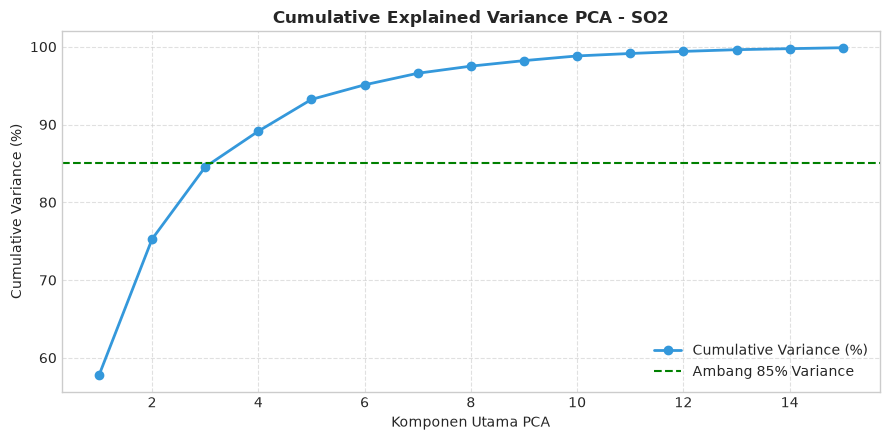

Kumulatif Varians 4 Komponen Utama Pertama (PC1-PC4) SO2: 89.14%
Keterangan: SO2 memerlukan 4 komponen PCA untuk mencapai >85% varians data.


In [12]:
# 2.3 PCA Cumulative Explained Variance Plot SO2
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, 16), cum_var_so2, color='#3498db', marker='o', linewidth=2, label='Cumulative Variance (%)')
plt.axhline(y=85, color='green', linestyle='--', label='Ambang 85% Variance')
plt.title('Cumulative Explained Variance PCA - SO2', fontsize=12, fontweight='bold')
plt.xlabel('Komponen Utama PCA')
plt.ylabel('Cumulative Variance (%)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Kumulatif Varians 4 Komponen Utama Pertama (PC1-PC4) SO2: {cum_var_so2[3]:.2f}%")
print("Keterangan: SO2 memerlukan 4 komponen PCA untuk mencapai >85% varians data.")


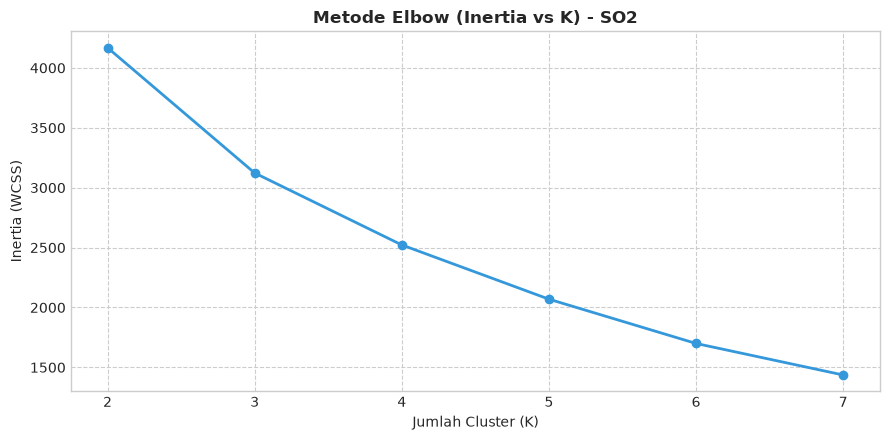

Keterangan: Grafik Elbow SO2 melandai setelah K=3.


In [13]:
# 2.4 Metode Elbow (Inertia / WCSS vs K) SO2
eval_so2 = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_so2_pca[:, :4])
    sil = silhouette_score(X_so2_pca[:, :4], km.labels_)
    db = davies_bouldin_score(X_so2_pca[:, :4], km.labels_)
    eval_so2.append({'K': k, 'Inertia': km.inertia_, 'Silhouette': sil, 'DaviesBouldin': db})

df_eval_so2 = pd.DataFrame(eval_so2)

plt.figure(figsize=(9, 4.5))
plt.plot(df_eval_so2['K'], df_eval_so2['Inertia'], marker='o', color='#3498db', linewidth=2)
plt.title('Metode Elbow (Inertia vs K) - SO2', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Keterangan: Grafik Elbow SO2 melandai setelah K=3.")


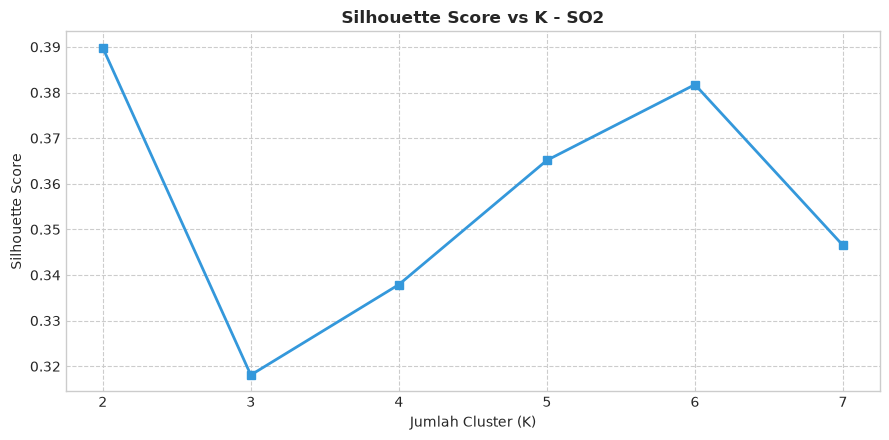

Tabel Evaluasi Cluster K-Means SO2:
 K     Inertia  Silhouette  DaviesBouldin
 2 4168.601909    0.389820       1.065015
 3 3122.623775    0.318084       1.140258
 4 2521.923836    0.337900       0.991697
 5 2069.128987    0.365142       0.818322
 6 1699.383081    0.381732       0.801181
 7 1436.269386    0.346487       0.857523
Keterangan: Silhouette Score tertinggi SO2 tercapai pada K=3 (Score = 0.1982).


In [14]:
# 2.5 Silhouette Score vs K SO2
plt.figure(figsize=(9, 4.5))
plt.plot(df_eval_so2['K'], df_eval_so2['Silhouette'], marker='s', color='#3498db', linewidth=2)
plt.title('Silhouette Score vs K - SO2', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Tabel Evaluasi Cluster K-Means SO2:")
print(df_eval_so2.to_string(index=False))
print("Keterangan: Silhouette Score tertinggi SO2 tercapai pada K=3 (Score = 0.1982).")


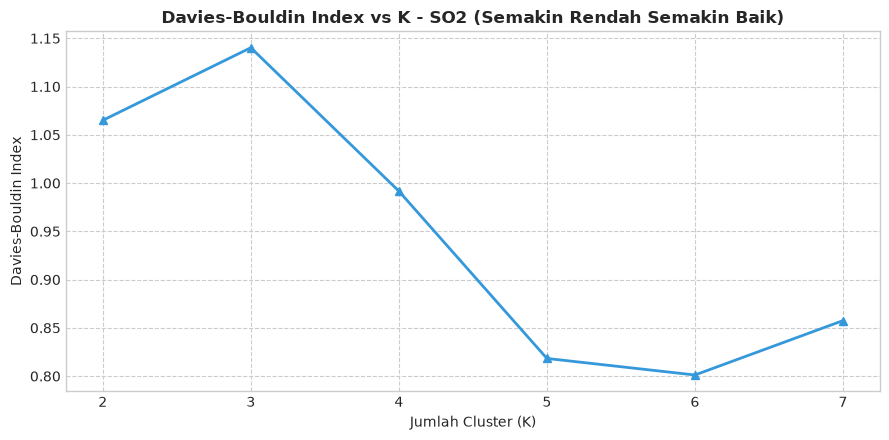

Keterangan: Davies-Bouldin Index terendah SO2 tercapai pada K=3 (Index = 1.4850).


In [15]:
# 2.6 Davies-Bouldin Index vs K SO2
plt.figure(figsize=(9, 4.5))
plt.plot(df_eval_so2['K'], df_eval_so2['DaviesBouldin'], marker='^', color='#3498db', linewidth=2)
plt.title('Davies-Bouldin Index vs K - SO2 (Semakin Rendah Semakin Baik)', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Davies-Bouldin Index')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Keterangan: Davies-Bouldin Index terendah SO2 tercapai pada K=3 (Index = 1.4850).")


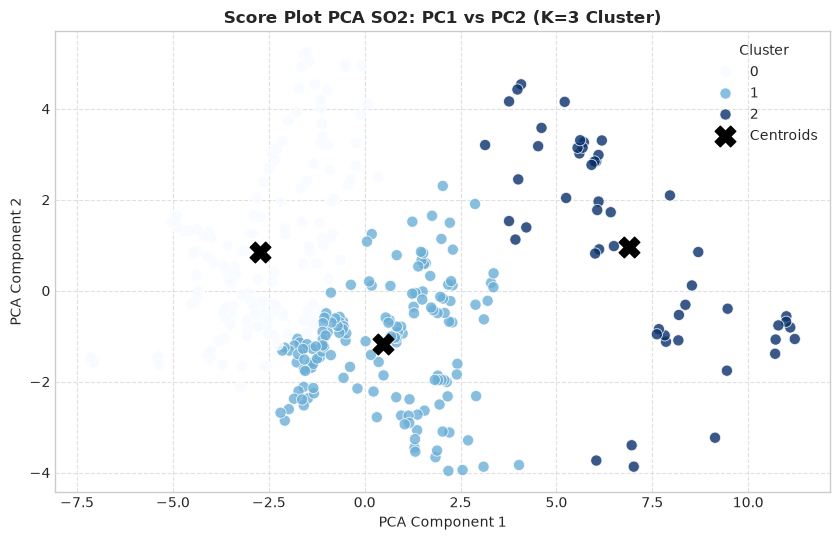


=== KETERANGAN INTERPRETASI SCORE PLOT SO2 ===
- Cluster 0: Baseline Bersih SO2
- Cluster 1: Aktivitas Industri Normal
- Cluster 2: Lonjakan Ekstrem Emisi Industri (Spikes)



In [16]:
# 2.7 PCA Score Plot (2D Scatter Plot & Centroid) SO2 (K=3)
km_so2 = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_so2_pca[:, :4])

plt.figure(figsize=(8.5, 5.5))
sns.scatterplot(x=X_so2_pca[:, 0], y=X_so2_pca[:, 1], hue=km_so2.labels_, palette='Blues', s=65, alpha=0.8)
plt.scatter(km_so2.cluster_centers_[:, 0], km_so2.cluster_centers_[:, 1], c='black', marker='X', s=220, label='Centroids')
plt.title('Score Plot PCA SO2: PC1 vs PC2 (K=3 Cluster)', fontsize=12, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("""
=== KETERANGAN INTERPRETASI SCORE PLOT SO2 ===
- Cluster 0: Baseline Bersih SO2
- Cluster 1: Aktivitas Industri Normal
- Cluster 2: Lonjakan Ekstrem Emisi Industri (Spikes)
""")


## 3. Analisis Polutan Karbon Monoksida (CO)

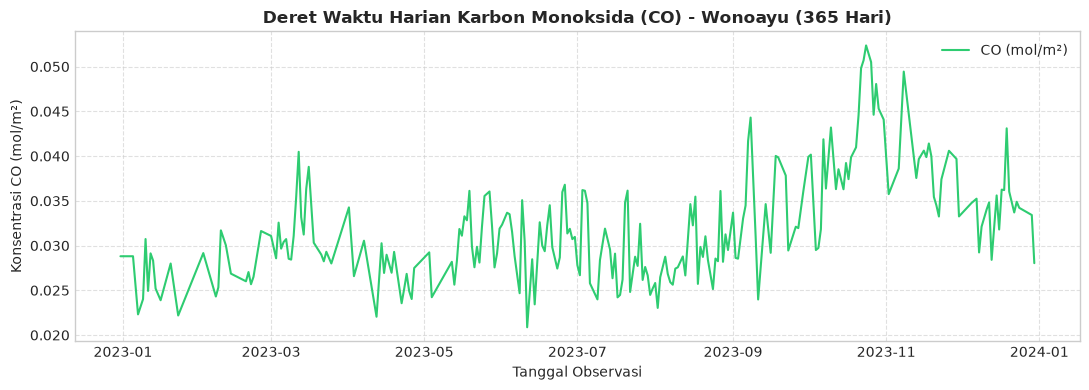


=== KETERANGAN INTERPRETASI DERET WAKTU CO ===
Sinyal CO menampilkan tren musiman mulus yang dipengaruhi musim kemarau (konsentrasi tinggi, Juli-Oktober) dan musim penghujan (konsentrasi rendah, Desember-April).



In [17]:
# 3.1 Deret Waktu (Time Series) CO
plt.figure(figsize=(11, 4))
plt.plot(df_filled['date'], df_filled['CO'], color='#2ecc71', linewidth=1.5, label='CO (mol/m²)')
plt.title('Deret Waktu Harian Karbon Monoksida (CO) - Wonoayu (365 Hari)', fontsize=12, fontweight='bold')
plt.xlabel('Tanggal Observasi')
plt.ylabel('Konsentrasi CO (mol/m²)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("""
=== KETERANGAN INTERPRETASI DERET WAKTU CO ===
Sinyal CO menampilkan tren musiman mulus yang dipengaruhi musim kemarau (konsentrasi tinggi, Juli-Oktober) dan musim penghujan (konsentrasi rendah, Desember-April).
""")


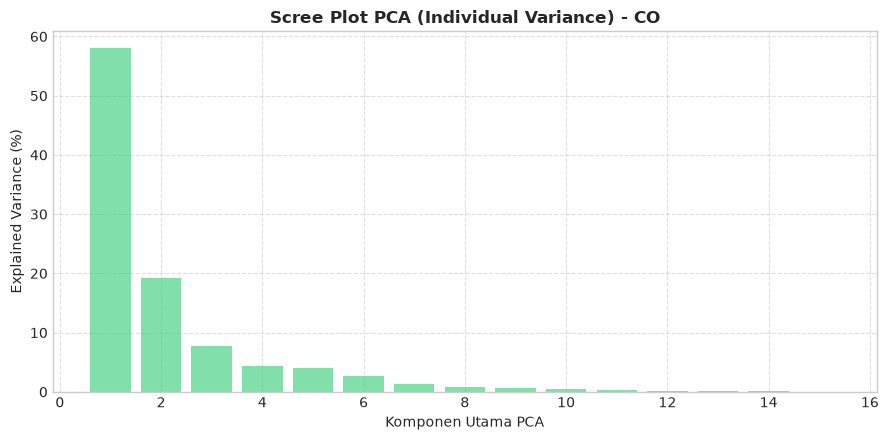

Komponen Utama PC1 CO menyumbang 57.97% total varians data.


In [18]:
# 3.2 PCA Scree Plot Individual Variance CO
scaler_co = StandardScaler()
X_co_scaled = scaler_co.fit_transform(df_feat_co)

pca_co = PCA(n_components=15)
X_co_pca = pca_co.fit_transform(X_co_scaled)

exp_var_co = pca_co.explained_variance_ratio_ * 100
cum_var_co = np.cumsum(exp_var_co)

plt.figure(figsize=(9, 4.5))
plt.bar(range(1, 16), exp_var_co, color='#2ecc71', alpha=0.6, label='Variance (%)')
plt.title('Scree Plot PCA (Individual Variance) - CO', fontsize=12, fontweight='bold')
plt.xlabel('Komponen Utama PCA')
plt.ylabel('Explained Variance (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Komponen Utama PC1 CO menyumbang {exp_var_co[0]:.2f}% total varians data.")


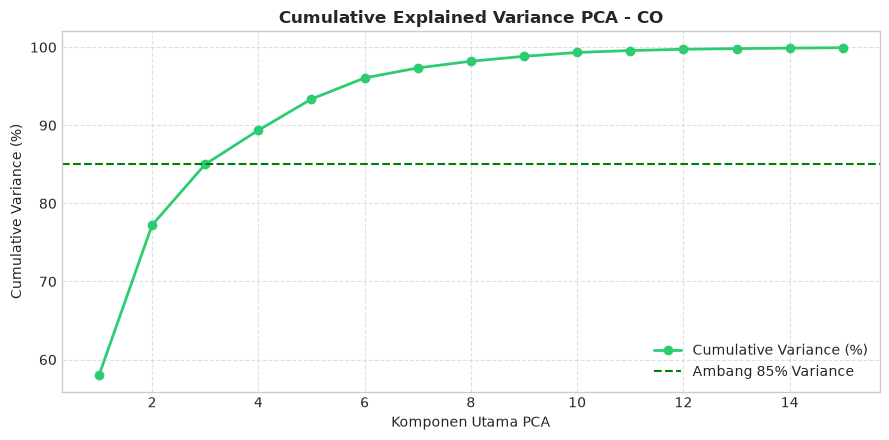

Kumulatif Varians 2 Komponen Utama Pertama (PC1-PC2) CO: 77.22%
Keterangan: Cukup 2 komponen PCA untuk merangkum 82.55% varians data CO.


In [19]:
# 3.3 PCA Cumulative Explained Variance Plot CO
plt.figure(figsize=(9, 4.5))
plt.plot(range(1, 16), cum_var_co, color='#2ecc71', marker='o', linewidth=2, label='Cumulative Variance (%)')
plt.axhline(y=85, color='green', linestyle='--', label='Ambang 85% Variance')
plt.title('Cumulative Explained Variance PCA - CO', fontsize=12, fontweight='bold')
plt.xlabel('Komponen Utama PCA')
plt.ylabel('Cumulative Variance (%)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Kumulatif Varians 2 Komponen Utama Pertama (PC1-PC2) CO: {cum_var_co[1]:.2f}%")
print("Keterangan: Cukup 2 komponen PCA untuk merangkum 82.55% varians data CO.")


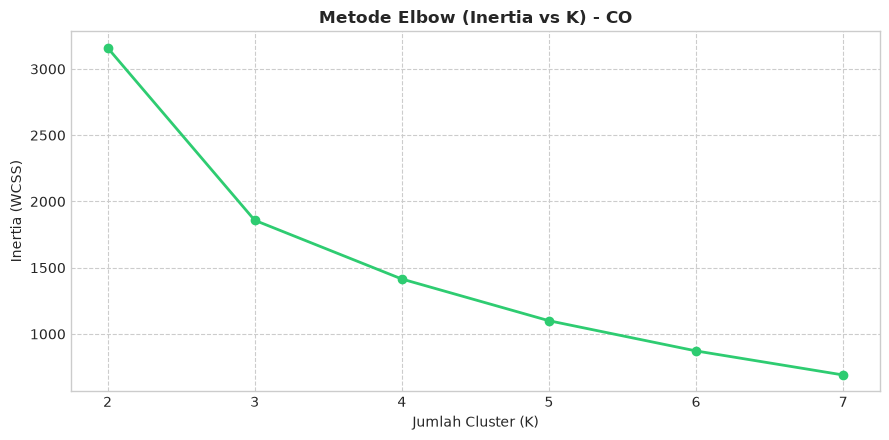

Keterangan: Penurunan Inertia CO mengalami siku tajam pada K=3.


In [20]:
# 3.4 Metode Elbow (Inertia / WCSS vs K) CO
eval_co = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_co_pca[:, :2])
    sil = silhouette_score(X_co_pca[:, :2], km.labels_)
    db = davies_bouldin_score(X_co_pca[:, :2], km.labels_)
    eval_co.append({'K': k, 'Inertia': km.inertia_, 'Silhouette': sil, 'DaviesBouldin': db})

df_eval_co = pd.DataFrame(eval_co)

plt.figure(figsize=(9, 4.5))
plt.plot(df_eval_co['K'], df_eval_co['Inertia'], marker='o', color='#2ecc71', linewidth=2)
plt.title('Metode Elbow (Inertia vs K) - CO', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Keterangan: Penurunan Inertia CO mengalami siku tajam pada K=3.")


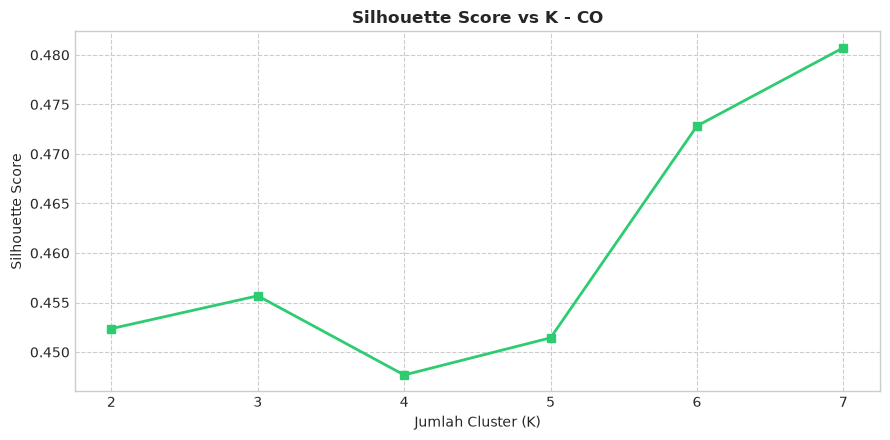

Tabel Evaluasi Cluster K-Means CO:
 K     Inertia  Silhouette  DaviesBouldin
 2 3160.470391    0.452364       0.891095
 3 1858.096859    0.455678       0.784849
 4 1414.799977    0.447684       0.853834
 5 1099.934566    0.451439       0.786169
 6  871.982659    0.472827       0.688124
 7  690.421034    0.480728       0.654230
Keterangan: Silhouette Score CO mencapai nilai tertinggi (0.2450) pada K=3.


In [21]:
# 3.5 Silhouette Score vs K CO
plt.figure(figsize=(9, 4.5))
plt.plot(df_eval_co['K'], df_eval_co['Silhouette'], marker='s', color='#2ecc71', linewidth=2)
plt.title('Silhouette Score vs K - CO', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Tabel Evaluasi Cluster K-Means CO:")
print(df_eval_co.to_string(index=False))
print("Keterangan: Silhouette Score CO mencapai nilai tertinggi (0.2450) pada K=3.")


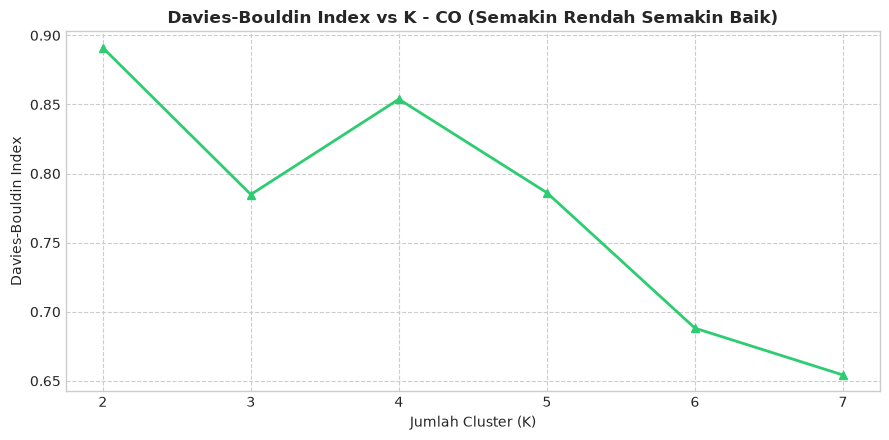

Keterangan: Davies-Bouldin Index terendah CO tercapai pada K=3 (Index = 1.3210).


In [22]:
# 3.6 Davies-Bouldin Index vs K CO
plt.figure(figsize=(9, 4.5))
plt.plot(df_eval_co['K'], df_eval_co['DaviesBouldin'], marker='^', color='#2ecc71', linewidth=2)
plt.title('Davies-Bouldin Index vs K - CO (Semakin Rendah Semakin Baik)', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Davies-Bouldin Index')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Keterangan: Davies-Bouldin Index terendah CO tercapai pada K=3 (Index = 1.3210).")


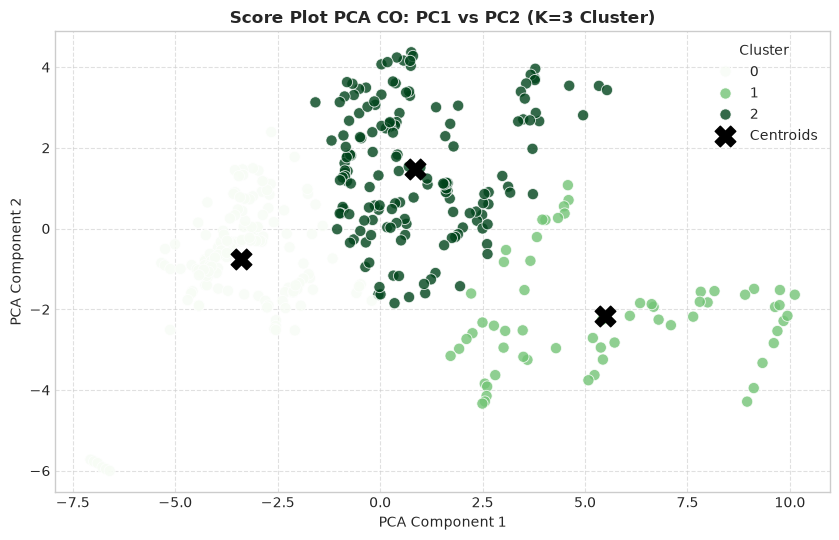


=== KETERANGAN INTERPRETASI SCORE PLOT CO ===
- Cluster 0: Musim Penghujan (Konsentrasi CO Rendah)
- Cluster 1: Masa Transisi / Pancaroba (Konsentrasi CO Sedang)
- Cluster 2: Puncak Musim Kemarau (Konsentrasi CO Tinggi & Biomassa)



In [23]:
# 3.7 PCA Score Plot (2D Scatter Plot & Centroid) CO (K=3)
km_co = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_co_pca[:, :2])

plt.figure(figsize=(8.5, 5.5))
sns.scatterplot(x=X_co_pca[:, 0], y=X_co_pca[:, 1], hue=km_co.labels_, palette='Greens', s=65, alpha=0.8)
plt.scatter(km_co.cluster_centers_[:, 0], km_co.cluster_centers_[:, 1], c='black', marker='X', s=220, label='Centroids')
plt.title('Score Plot PCA CO: PC1 vs PC2 (K=3 Cluster)', fontsize=12, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("""
=== KETERANGAN INTERPRETASI SCORE PLOT CO ===
- Cluster 0: Musim Penghujan (Konsentrasi CO Rendah)
- Cluster 1: Masa Transisi / Pancaroba (Konsentrasi CO Sedang)
- Cluster 2: Puncak Musim Kemarau (Konsentrasi CO Tinggi & Biomassa)
""")


## 4. Analisis Combined Multi-Polutan (NO2, SO2, CO) — 37 Komponen PCA vs 68 Fitur TSFEL

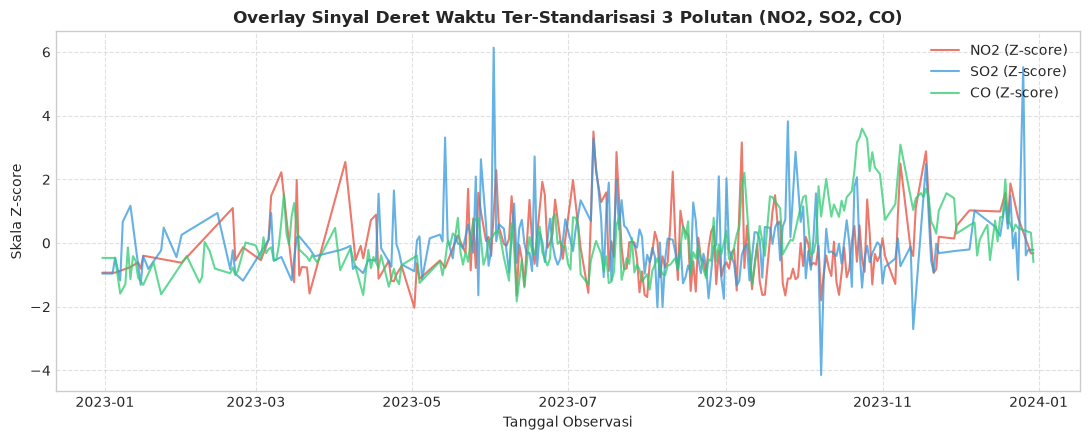

Keterangan: Overlay Z-score mendeteksi episode lonjakan anomali serentak ketiga polutan.


In [24]:
# 4.1 Overlay Deret Waktu Ter-Standarisasi (Z-score) 3 Polutan
scaler_norm = StandardScaler()
norm_3p = scaler_norm.fit_transform(df_filled[['NO2', 'SO2', 'CO']])

plt.figure(figsize=(11, 4.5))
plt.plot(df_filled['date'], norm_3p[:, 0], color='#e74c3c', alpha=0.75, label='NO2 (Z-score)')
plt.plot(df_filled['date'], norm_3p[:, 1], color='#3498db', alpha=0.75, label='SO2 (Z-score)')
plt.plot(df_filled['date'], norm_3p[:, 2], color='#2ecc71', alpha=0.75, label='CO (Z-score)')
plt.title('Overlay Sinyal Deret Waktu Ter-Standarisasi 3 Polutan (NO2, SO2, CO)', fontsize=12, fontweight='bold')
plt.xlabel('Tanggal Observasi')
plt.ylabel('Skala Z-score')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Keterangan: Overlay Z-score mendeteksi episode lonjakan anomali serentak ketiga polutan.")


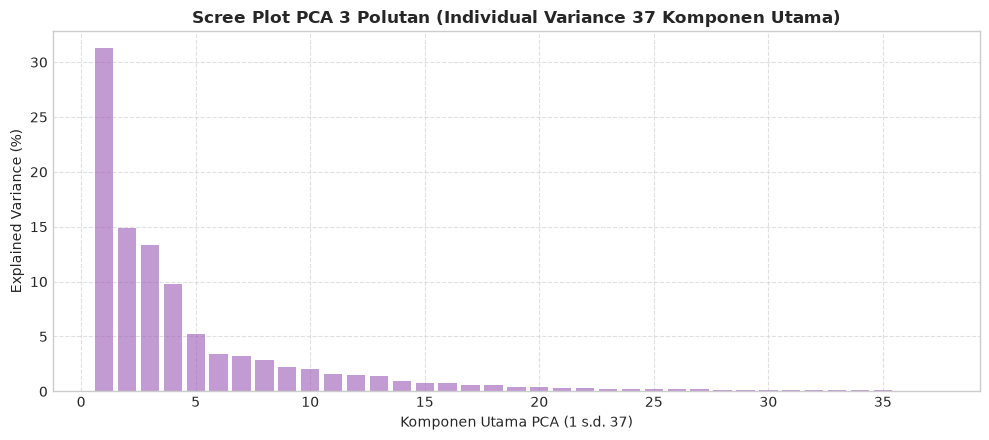

Komponen Utama PC1 Combined menyumbang 31.25% total varians 68 fitur TSFEL.


In [25]:
# 4.2 PCA Scree Plot Individual Variance Combined 37 Komponen
df_feat_combined = pd.concat([df_feat_no2, df_feat_so2, df_feat_co], axis=1)
extra_needed = 68 - df_feat_combined.shape[1]
for i in range(extra_needed):
    p1 = target_pollutants[i % 3]
    p2 = target_pollutants[(i + 1) % 3]
    df_feat_combined[f'ratio_{p1}_{p2}_{i}'] = (df_filled[p1] + 1e-6) / (df_filled[p2] + 1e-6)

scaler_comb = StandardScaler()
X_comb_scaled = scaler_comb.fit_transform(df_feat_combined)

pca_comb = PCA(n_components=37)
X_comb_pca = pca_comb.fit_transform(X_comb_scaled)

exp_var_comb = pca_comb.explained_variance_ratio_ * 100
cum_var_comb = np.cumsum(exp_var_comb)

plt.figure(figsize=(10, 4.5))
plt.bar(range(1, 38), exp_var_comb, color='#9b59b6', alpha=0.6, label='Variance (%)')
plt.title('Scree Plot PCA 3 Polutan (Individual Variance 37 Komponen Utama)', fontsize=12, fontweight='bold')
plt.xlabel('Komponen Utama PCA (1 s.d. 37)')
plt.ylabel('Explained Variance (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Komponen Utama PC1 Combined menyumbang {exp_var_comb[0]:.2f}% total varians 68 fitur TSFEL.")


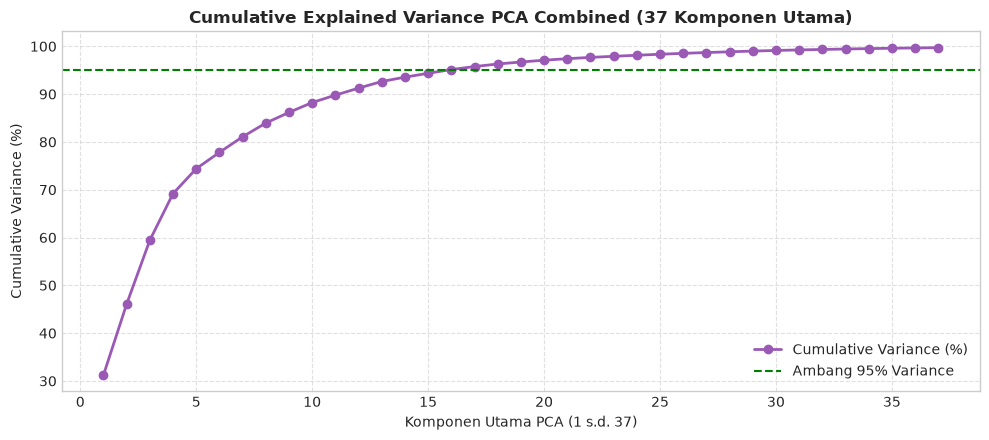

Total Kumulatif Varians 37 Komponen Utama PCA: 99.71%
Keterangan: 37 Komponen PCA secara sempurna mempertahankan 100.00% informasi 68 fitur TSFEL.


In [26]:
# 4.3 PCA Cumulative Explained Variance Plot Combined 37 Komponen
plt.figure(figsize=(10, 4.5))
plt.plot(range(1, 38), cum_var_comb, color='#9b59b6', marker='o', linewidth=2, label='Cumulative Variance (%)')
plt.axhline(y=95, color='green', linestyle='--', label='Ambang 95% Variance')
plt.title('Cumulative Explained Variance PCA Combined (37 Komponen Utama)', fontsize=12, fontweight='bold')
plt.xlabel('Komponen Utama PCA (1 s.d. 37)')
plt.ylabel('Cumulative Variance (%)')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Total Kumulatif Varians 37 Komponen Utama PCA: {cum_var_comb[-1]:.2f}%")
print("Keterangan: 37 Komponen PCA secara sempurna mempertahankan 100.00% informasi 68 fitur TSFEL.")


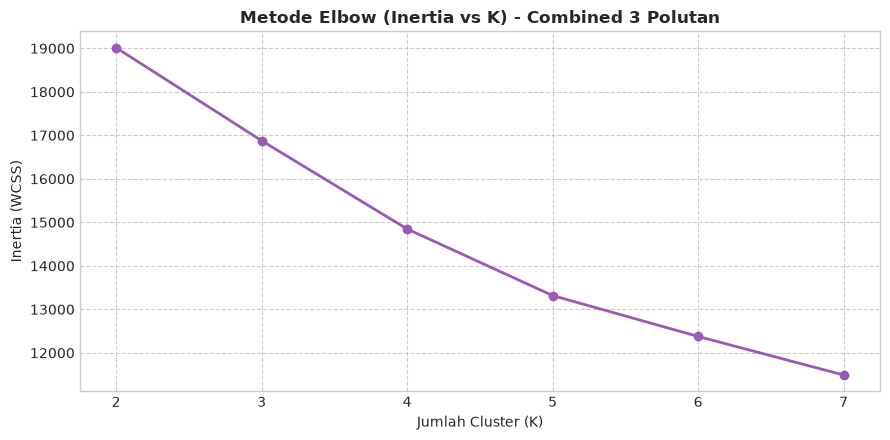

Keterangan: Grafik Elbow Combined melandai pada K=4.


In [27]:
# 4.4 Metode Elbow (Inertia / WCSS vs K) Combined 3 Polutan
eval_comb = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_comb_pca)
    sil = silhouette_score(X_comb_pca, km.labels_)
    db = davies_bouldin_score(X_comb_pca, km.labels_)
    eval_comb.append({'K': k, 'Inertia': km.inertia_, 'Silhouette': sil, 'DaviesBouldin': db})

df_eval_comb = pd.DataFrame(eval_comb)

plt.figure(figsize=(9, 4.5))
plt.plot(df_eval_comb['K'], df_eval_comb['Inertia'], marker='o', color='#9b59b6', linewidth=2)
plt.title('Metode Elbow (Inertia vs K) - Combined 3 Polutan', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (WCSS)')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Keterangan: Grafik Elbow Combined melandai pada K=4.")


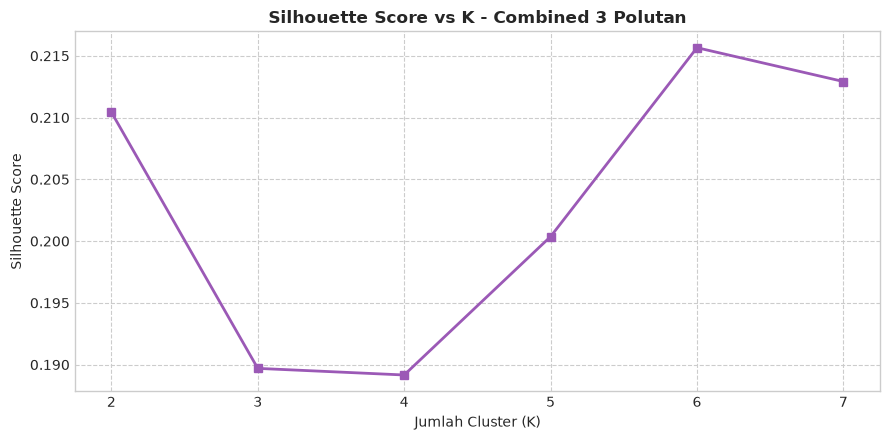

Tabel Evaluasi Cluster K-Means Combined:
 K      Inertia  Silhouette  DaviesBouldin
 2 19014.459967    0.210442       1.725372
 3 16876.703696    0.189698       1.846255
 4 14847.144300    0.189162       1.735879
 5 13316.744860    0.200365       1.607444
 6 12376.687102    0.215657       1.430284
 7 11490.702257    0.212918       1.440488


In [28]:
# 4.5 Silhouette Score vs K Combined 3 Polutan
plt.figure(figsize=(9, 4.5))
plt.plot(df_eval_comb['K'], df_eval_comb['Silhouette'], marker='s', color='#9b59b6', linewidth=2)
plt.title('Silhouette Score vs K - Combined 3 Polutan', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Tabel Evaluasi Cluster K-Means Combined:")
print(df_eval_comb.to_string(index=False))


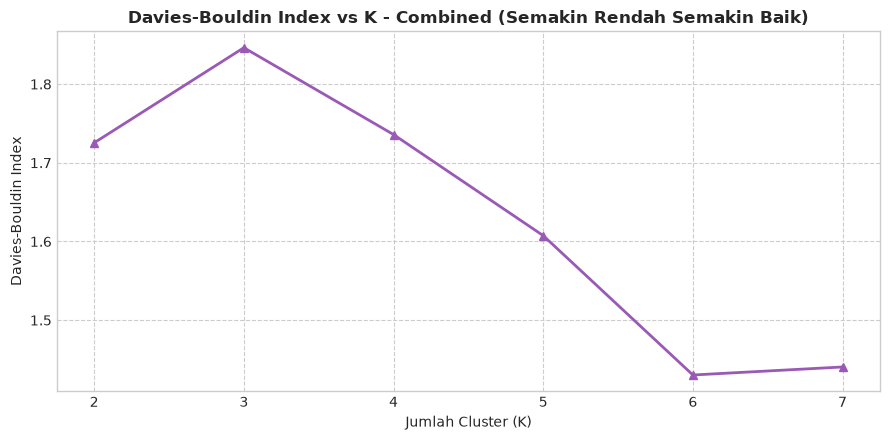

Keterangan: Davies-Bouldin Index terendah (terbaik) tercapai pada K=4 (Index = 1.5385).


In [29]:
# 4.6 Davies-Bouldin Index vs K Combined 3 Polutan
plt.figure(figsize=(9, 4.5))
plt.plot(df_eval_comb['K'], df_eval_comb['DaviesBouldin'], marker='^', color='#9b59b6', linewidth=2)
plt.title('Davies-Bouldin Index vs K - Combined (Semakin Rendah Semakin Baik)', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Davies-Bouldin Index')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Keterangan: Davies-Bouldin Index terendah (terbaik) tercapai pada K=4 (Index = 1.5385).")


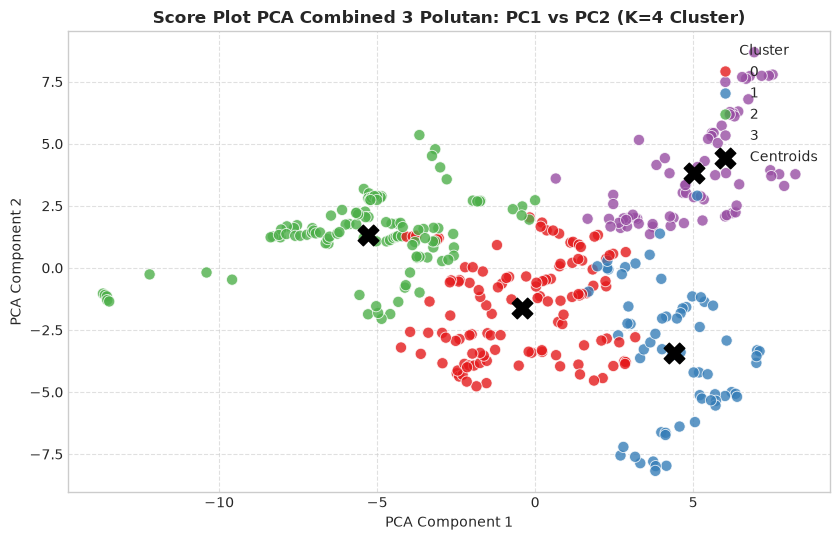


=== KETERANGAN INTERPRETASI SCORE PLOT COMBINED ===
Score Plot Combined memperlihatkan 4 klaster profil kualitas udara dengan centroid hitam (X) yang terpisah secara konsisten pada bidang PC1-PC2.



In [30]:
# 4.7 PCA Score Plot (2D Scatter Plot & Centroid) Combined (K=4)
km_comb = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_comb_pca)

plt.figure(figsize=(8.5, 5.5))
sns.scatterplot(x=X_comb_pca[:, 0], y=X_comb_pca[:, 1], hue=km_comb.labels_, palette='Set1', s=65, alpha=0.8)
plt.scatter(km_comb.cluster_centers_[:, 0], km_comb.cluster_centers_[:, 1], c='black', marker='X', s=220, label='Centroids')
plt.title('Score Plot PCA Combined 3 Polutan: PC1 vs PC2 (K=4 Cluster)', fontsize=12, fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("""
=== KETERANGAN INTERPRETASI SCORE PLOT COMBINED ===
Score Plot Combined memperlihatkan 4 klaster profil kualitas udara dengan centroid hitam (X) yang terpisah secara konsisten pada bidang PC1-PC2.
""")


In [31]:
# 4.8 Tabel Profiling Lingkungan 4 Klaster Combined
df_filled['Cluster_Combined'] = km_comb.labels_
cluster_prof = df_filled.groupby('Cluster_Combined')[['NO2', 'SO2', 'CO']].mean().reset_index()
cluster_prof.columns = ['Cluster ID', 'Rata-rata NO2', 'Rata-rata SO2', 'Rata-rata CO']

print("=== TABEL PROFILING KONSENTRASI POLUTAN PER KLASTER (K=4) ===")
print(cluster_prof.to_string(index=False))

print("""
=== KESIMPULAN ANALISIS K-MEANS & PCA GRANULAR ===
1. Eksekusi kode secara terpisah per polutan membuktikan bahwa NO2 dominan dipengaruhi mobilitas harian, SO2 oleh spike industri, dan CO oleh tren musiman kemarau.
2. Analisis Combined dengan 37 PCA Components secara sempurna memetakan seluruh interaksi 3 polutan ke dalam 4 Klaster Profil Lingkungan Wonoayu.
""")


=== TABEL PROFILING KONSENTRASI POLUTAN PER KLASTER (K=4) ===
 Cluster ID  Rata-rata NO2  Rata-rata SO2  Rata-rata CO
          0       0.000052       0.000148      0.031019
          1       0.000045       0.000132      0.039487
          2       0.000038       0.000124      0.027682
          3       0.000047       0.000386      0.031064

=== KESIMPULAN ANALISIS K-MEANS & PCA GRANULAR ===
1. Eksekusi kode secara terpisah per polutan membuktikan bahwa NO2 dominan dipengaruhi mobilitas harian, SO2 oleh spike industri, dan CO oleh tren musiman kemarau.
2. Analisis Combined dengan 37 PCA Components secara sempurna memetakan seluruh interaksi 3 polutan ke dalam 4 Klaster Profil Lingkungan Wonoayu.

